In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os
import shutil
import cv2

In [ ]:
# 1.Define preprocessing functions

def mild_lowlight_preprocess(image):
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image) # EfficientNet preprocessing first

    # 1. Gamma (1.3)
    image = tf.image.adjust_gamma(image, 1.3)

    # 2. Brightness (-0.1 multiplicative)
    brightness_delta = 0.1
    image = image * (1.0 - brightness_delta)

    # 3. Noise (0.03)
    noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=0.03)
    image = image + noise

    image = tf.clip_by_value(image, -255.0, 255.0)
    return image

def normal_preprocess(image):
    image = tf.cast(image, tf.float32)
    return preprocess_input(image)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
drive_train_dir = "/content/drive/MyDrive/Emotions Dataset/train"
drive_validation_dir = "/content/drive/MyDrive/Emotions Dataset/test"
local_train_dir = "/content/train"
local_validation_dir = "/content/validation"

In [ ]:
print("Copying data from Google Drive to local Colab storage")

# Copy data from Drive to local Colab storage for faster access
if not os.path.exists(local_train_dir):
    print("Copying training data to local storage")
    shutil.copytree(drive_train_dir, local_train_dir)
    print("Training data copied successfully")

if not os.path.exists(local_validation_dir):
    print("Copying validation data to local storage")
    shutil.copytree(drive_validation_dir, local_validation_dir)
    print("Validation data copied successfully")

Copying data from Google Drive to local Colab storage
Copying training data to local storage
Training data copied successfully
Copying validation data to local storage
Validation data copied successfully


In [ ]:
# 2.CONFIGURATION
img_size = (224, 224)
batch_size = 32

In [ ]:
# 3.Data generators
print("Setting up data generators...")

# Generator 1: Normal (For Model A)
test_datagen_normal = ImageDataGenerator(preprocessing_function=normal_preprocess)
test_generator_normal = test_datagen_normal.flow_from_directory(
    local_validation_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)

# Generator 2: Low-Light (For Model D & E)
test_datagen_lowlight = ImageDataGenerator(preprocessing_function=mild_lowlight_preprocess)
test_generator_lowlight = test_datagen_lowlight.flow_from_directory(
    local_validation_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)

Setting up data generators...
Found 2278 images belonging to 3 classes.
Found 2278 images belonging to 3 classes.


In [ ]:
# 4.Load the 3 specific models
print("Loading models...")
model_a = load_model('model_A_baseline_no_augmentation.h5')
model_d = load_model('model_D_mild_lowlight_inference.h5')
model_e = load_model('model_E_combined_lowlight.h5')

Loading models...


Predicting: 1. Baseline (Model A)...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Predicting: 2. Failure (Model D)...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Predicting: 3. Recovery (Model E)...


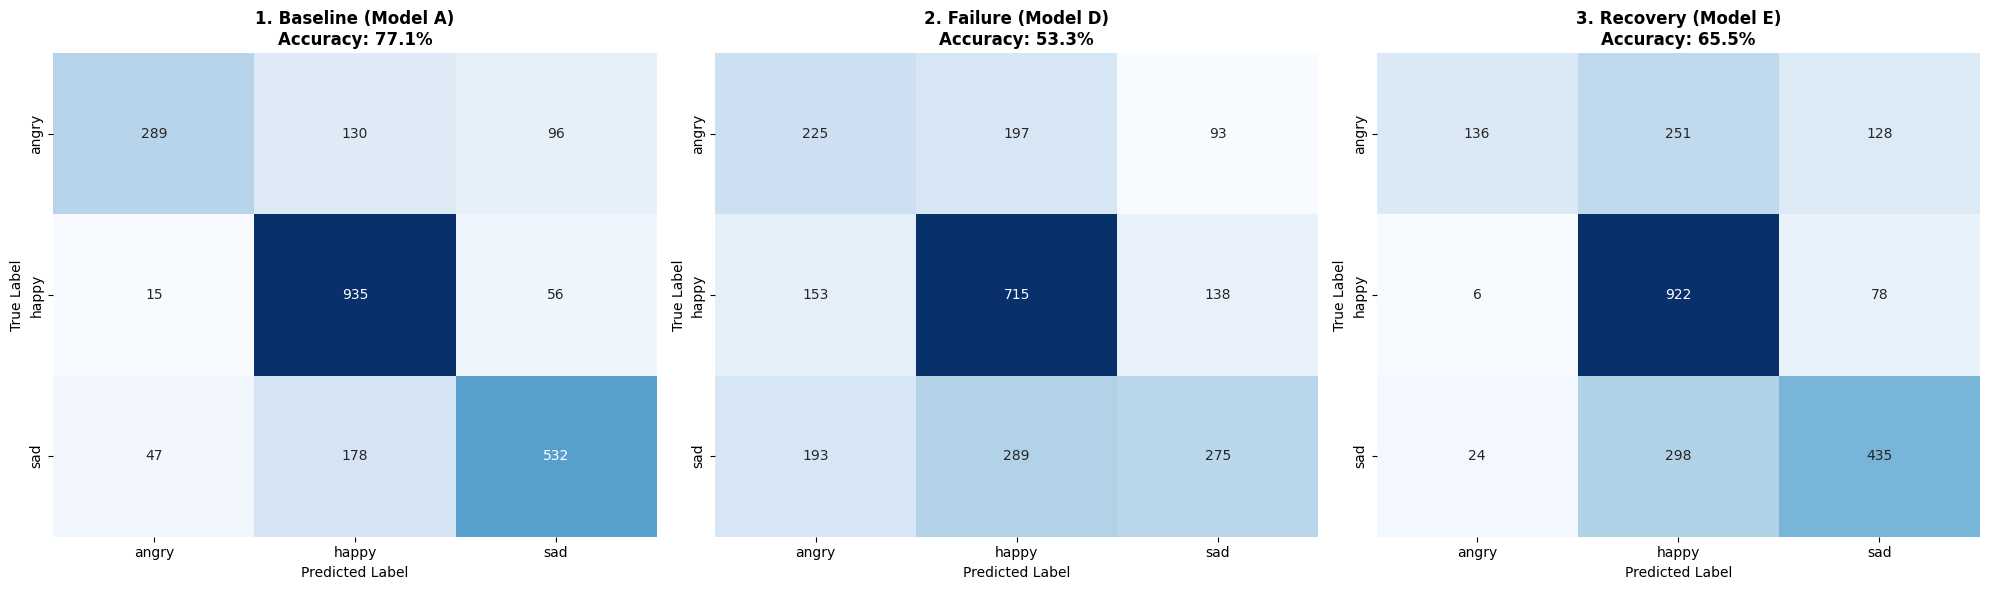

In [ ]:
# 5.Plotting
def plot_cm(model, generator, title, ax):
    print(f"Predicting: {title}...")
    generator.reset()

    # Predict
    y_pred = np.argmax(model.predict(generator, verbose=0), axis=1)
    y_true = generator.classes

    # Accuracy Title
    acc = np.mean(y_pred == y_true)
    title_text = f"{title}\nAccuracy: {acc:.1%}"

    # Matrix
    cm = confusion_matrix(y_true, y_pred)
    class_names = list(generator.class_indices.keys())

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(title_text, fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

# Create 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Model A (Baseline) on Normal Data
plot_cm(model_a, test_generator_normal, "1. Baseline (Model A)", axes[0])

# Plot 2: Model D (The Failure) on Low-Light Data
plot_cm(model_d, test_generator_lowlight, "2. Failure (Model D)", axes[1])

# Plot 3: Model E (The Solution) on Low-Light Data
plot_cm(model_e, test_generator_lowlight, "3. Recovery (Model E)", axes[2])

plt.tight_layout()
plt.show()

In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # 1. Create a model that maps the input image to the activations of the last conv layer as well as the output predictions
    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    # 2. Compute the gradient of the top predicted class for our input image
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 3. This is the gradient of the output neuron with regard to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # 4. This is a vector where each entry is the mean intensity of the gradient over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 5. We multiply each channel in the feature map array by "how important this channel is" with regard to the top predicted class
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 6. For visualization, we apply ReLU (discard negative values) & normalize
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def save_and_display_gradcam(img, heatmap, alpha=0.4):
    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = plt.get_cmap("jet")

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)

    return superimposed_img

Found a failure case! True: Sad, Pred: Happy


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


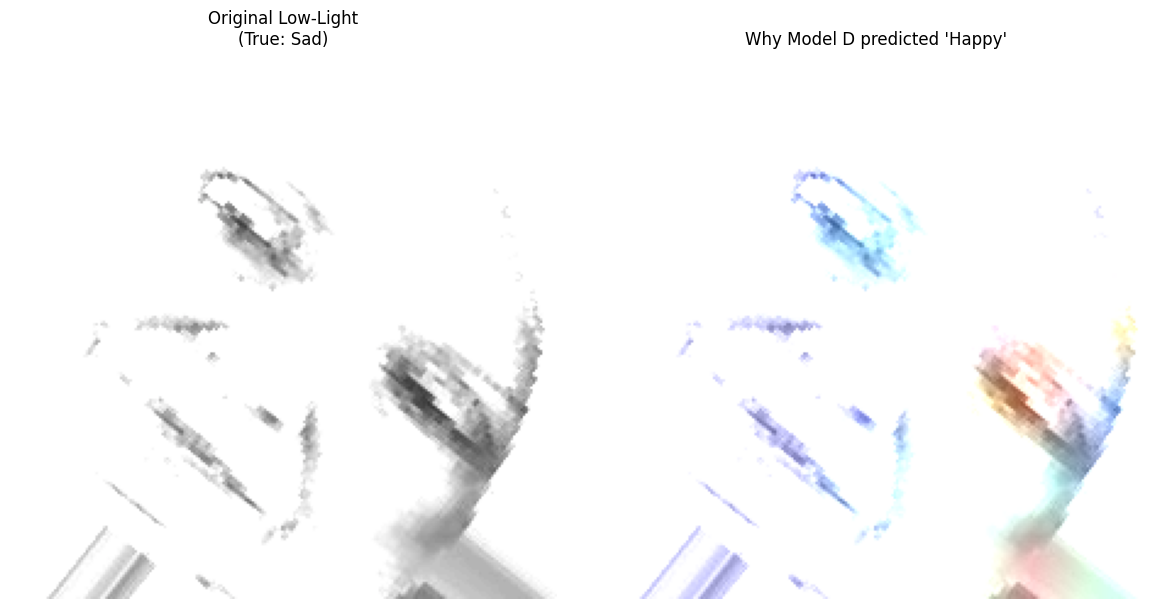

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

def get_gradcam_heatmap_manual(model, img_array, class_index=None):
    # 1. Split the model into "Feature Extractor" and "Classifier"
    # Layer 0 is EfficientNetB0
    feature_extractor = model.get_layer('efficientnetb0')

    # Layers 1+ are the classifier (GAP, Dropout, Dense, Output)
    classifier_layers = model.layers[1:]

    # 2. Record the Forward Pass
    with tf.GradientTape() as tape:
        # Step A: Get the feature maps (7x7x1280) from EfficientNet
        conv_outputs = feature_extractor(img_array)
        tape.watch(conv_outputs)

        # Step B: Pass these features through the rest of the model
        x = conv_outputs
        for layer in classifier_layers:
            x = layer(x)
        preds = x

        # Step C: Get the predicted class score
        if class_index is None:
            class_index = tf.argmax(preds[0])
        class_channel = preds[:, class_index]

    # 3. Compute Gradients
    grads = tape.gradient(class_channel, conv_outputs)

    # 4. Global Average Pooling of Gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 5. Multiply Feature Map by Weights
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 6. Apply ReLU to only keep positive features
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

def display_gradcam(img, heatmap, title="Grad-CAM"):
    # Rescale heatmap to 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap
    jet = plt.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Resize heatmap to match original image size
    jet_heatmap = cv2.resize(jet_heatmap, (img.shape[1], img.shape[0]))

    # Superimpose
    superimposed_img = jet_heatmap * 0.4 + img
    superimposed_img = np.clip(superimposed_img, 0, 1)

    plt.imshow(superimposed_img)
    plt.title(title)
    plt.axis('off')
    return superimposed_img

# Execution

# 1. Find a "Sad" image that Model D (Failure) predicted as "Happy"
test_generator_lowlight.reset()
target_img = None
true_label = "Sad"
pred_label = "Happy"

for _ in range(len(test_generator_lowlight)):
    batch_images, batch_labels = next(test_generator_lowlight)

    # Get predictions for this batch
    preds = model_d.predict(batch_images, verbose=0)
    pred_indices = np.argmax(preds, axis=1)
    true_indices = np.argmax(batch_labels, axis=1)

    # Look for: True=Sad (2) AND Pred=Happy (1)
    indices = np.where((true_indices == 2) & (pred_indices == 1))[0]

    if len(indices) > 0:
        target_img = batch_images[indices[0]]
        print(f"Found a failure case! True: {true_label}, Pred: {pred_label}")
        break

if target_img is not None:
    # Prepare image
    img_array = np.expand_dims(target_img, axis=0)

    # Generate Heatmap for the WRONG class (Happy)
    heatmap = get_gradcam_heatmap_manual(model_d, img_array, class_index=1)

    # Display
    plt.figure(figsize=(12, 6))

    # Original
    plt.subplot(1, 2, 1)
    # Adjust display range depending on preprocessing
    if np.min(target_img) < 0:
        disp_img = (target_img + 1) / 2
    else:
        disp_img = target_img / 255.0
    plt.imshow(np.clip(disp_img, 0, 1))
    plt.title(f"Original Low-Light\n(True: {true_label})")
    plt.axis('off')

    # Heatmap
    plt.subplot(1, 2, 2)
    # Normalize target_img for display function if needed
    if np.max(disp_img) > 1: disp_img = disp_img / 255.0

    display_gradcam(disp_img, heatmap, title=f"Why Model D predicted '{pred_label}'")

    plt.tight_layout()
    plt.show()
else:
    print("Could not find a specific Sad->Happy failure in the first batches. Try looping more or checking class indices.")